
# Árboles de Expansión Mínima (MST)

# Definición del Problema


- Grafo **no dirigido** $ G(\mathcal{N}, \mathcal{A}) $
  - $ (i,j) = (j,i) $
  - $ c_{ij} $ costo del arco $ (i,j) \in \mathcal{A} $
  - $ n = |\mathcal{N}|, m = |\mathcal{A}| $

- Un **árbol generatriz** $ T $ de $ G $ es un subgrafo acíclico que genera todos los nodos de $ G $ y está conectado por $ n - 1 $ arcos.

- El **árbol generatriz mínimo** es el problema de encontrar un árbol generatriz de **mínimo costo**.


### Aplicaciones
1. **Diseño de redes**: Encontrar el camino más corto para conectar una red de computadoras o líneas de comunicación.
2. **Agrupamiento de datos (clustering)**: Agrupar puntos basados en distancia.


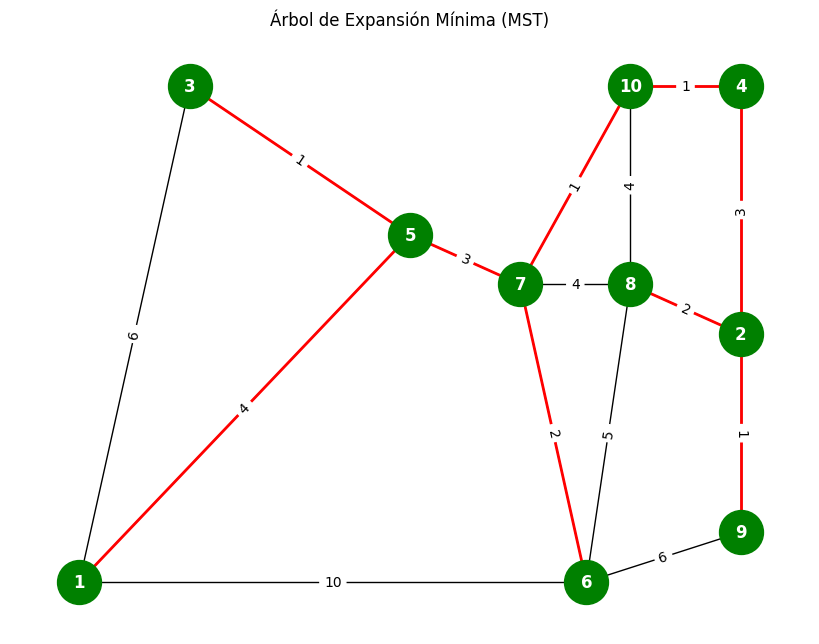

In [73]:
import matplotlib.pyplot as plt
import networkx as nx

# Crear el grafo
G = nx.Graph()

# Añadir nodos
nodes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
G.add_nodes_from(nodes)

# Añadir aristas con sus pesos
edges = [
    (1, 3, 6), (1, 5, 4), (1, 6, 10), 
    (2, 4, 3), (2, 8, 2), (2, 9, 1), 
    (3, 5, 1), 
    (4, 10, 1), 
    (5, 7, 3),  
    (6, 7, 2), (6, 8, 5), (6, 9, 6), 
    (7, 8, 4), 
    (8, 10, 4), 
    (9, 2, 1), 
    (10, 7, 1)
]

G.add_weighted_edges_from(edges)

# Encontrar el árbol de expansión mínima (MST)
mst = nx.minimum_spanning_tree(G)

# Posiciones de los nodos
pos = {
    1: (0, 0),   # nodo 1
    2: (3, 0.5),   # nodo 2
    3: (0.5, 1),  # nodo 3
    4: (3.0, 1),  # nodo 4
    5: (1.5, 0.7),   # nodo 5
    6: (2.3, 0),  # nodo 6
    7: (2, 0.6),  # nodo 7
    8: (2.5, 0.6),   # nodo 8
    9: (3, 0.1),    # nodo 9
    10: (2.5, 1)  # nodo 10
}



# Dibujar el grafo
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color='green', node_size=1000, font_weight='bold', font_color='white', edge_color='black')

# Dibujar las aristas del árbol de expansión mínima (MST)
nx.draw_networkx_edges(G, pos, edgelist=mst.edges(), edge_color='red', width=2)

# Dibujar etiquetas con los pesos de las aristas
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Mostrar el gráfico
plt.title("Árbol de Expansión Mínima (MST)")
plt.show()


**Árbol generatriz**

Sea $ T^* $ un árbol generatriz.
- Los arcos en $ T^* $, son **“arcos del árbol”** (tree arcs).
- Los arcos que no están en $ T^* $, **“no son arcos del árbol”** (nontree arcs).

**Propiedades**


Sea $ T $ un árbol generatriz. Sea $ a $ un arco que no hace parte del árbol. Entonces, añadir $ a $ a $ T $ crea un ciclo único $ C $. Además, borrar cualquier arco de $ C $ crea un árbol generatriz $ T' $.



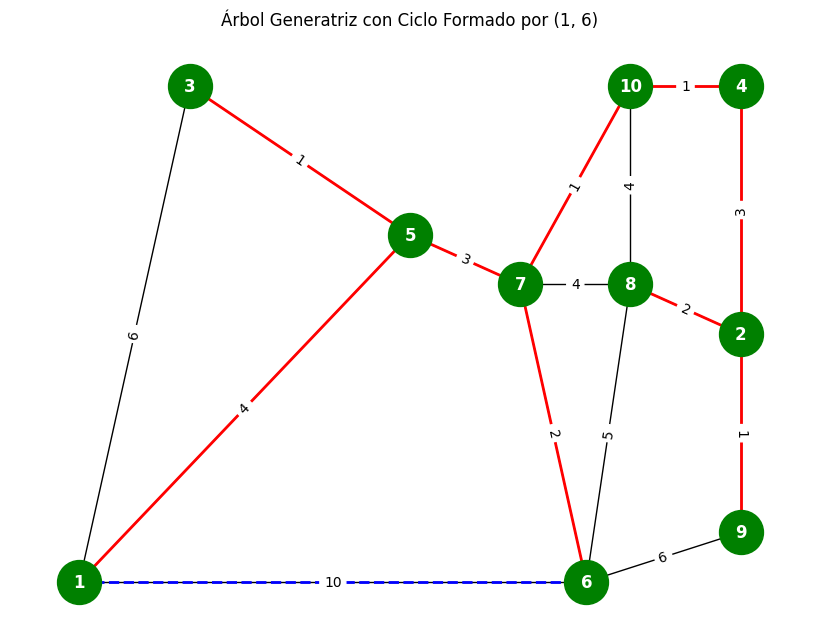

In [74]:
# Añadir el arco (1, 6) para formar un ciclo y visualizarlo
cycle_edge = (1, 6)

# Dibujar el grafo con el layout fijo
plt.figure(figsize=(8, 6))

# Dibujar nodos y aristas
nx.draw(G, pos, with_labels=True, node_color='green', node_size=1000, font_weight='bold', font_color='white', edge_color='black')

# Dibujar las aristas del árbol de expansión mínima (MST)
nx.draw_networkx_edges(G, pos, edgelist=mst.edges(), edge_color='red', width=2)

# Dibujar el arco adicional para formar el ciclo
nx.draw_networkx_edges(G, pos, edgelist=[cycle_edge], edge_color='blue', width=2, style='dashed')

# Dibujar etiquetas con los pesos de las aristas
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Mostrar el gráfico con el ciclo resaltado
plt.title("Árbol Generatriz con Ciclo Formado por (1, 6)")
plt.show()



## Algoritmo Greedy para MST

Uno de los enfoques más eficientes para encontrar un MST es usando algoritmos codiciosos como **Kruskal** y **Prim**, los cuales se basan en encontrar **aristas seguras** que no formen ciclos. Estas aristas se pueden identificar utilizando el concepto de **cortes** y **aristas ligeras**.



## Concepto de Cortes

Un **corte** $ (S, V - S) $ de un grafo es una partición de los vértices $ V $ en dos conjuntos disjuntos $ S $ y $ V - S $. Una **arista** se dice que **cruza el corte** si tiene un extremo en $ S $ y el otro en $ V - S $.




C:\Users\tabar\AppData\Local\Temp\ipykernel_16740\1921280182.py:14: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, edgelist=cut_edges, edge_color='blue', width=2)


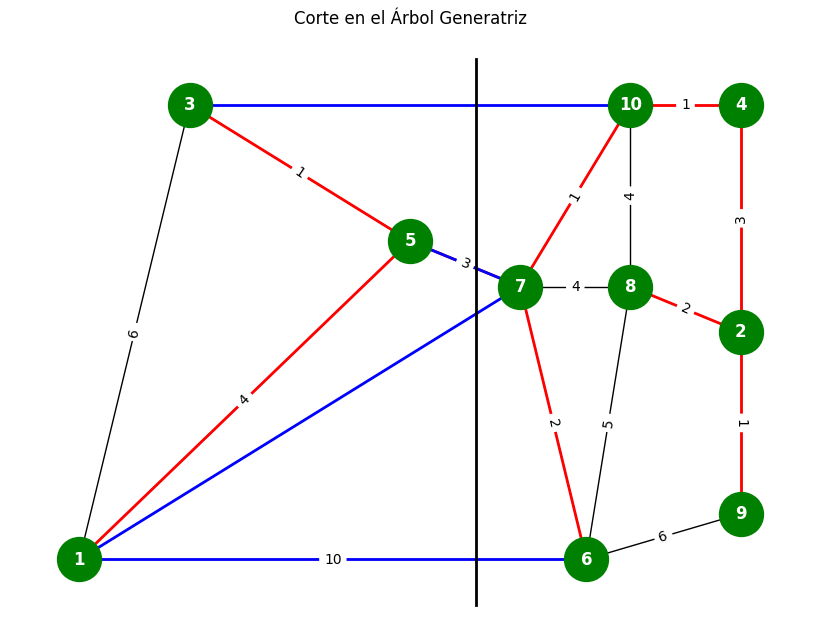

In [75]:
# Lista de los arcos resaltados en azul
cut_edges = [(3, 10), (5, 7), (1, 7), (1, 6)]

# Crear una figura
plt.figure(figsize=(8, 6))

# Dibujar los nodos y todas las aristas
nx.draw(G, pos, with_labels=True, node_color='green', node_size=1000, font_weight='bold', font_color='white', edge_color='black')

# Dibujar las aristas del árbol de expansión mínima (MST) en rojo
nx.draw_networkx_edges(G, pos, edgelist=mst.edges(), edge_color='red', width=2)

# Dibujar las aristas del corte en azul
nx.draw_networkx_edges(G, pos, edgelist=cut_edges, edge_color='blue', width=2)

# Dibujar etiquetas con los pesos de las aristas
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Dibujar una línea vertical entre los conjuntos
plt.plot([1.8,1.8], [-0.1, 1.1], color="black", linewidth=2)


# Mostrar el gráfico
plt.title("Corte en el Árbol Generatriz")
plt.show()


## Condiciones de optimalidad de corte

**Teorema**: Un árbol generatriz $ T^* $ es un árbol de mínima expansión si y sólo si $ T^* $ satisface las siguientes condiciones de optimalidad de corte:
- Para todo arco del árbol $ (i, j) \in T^* $, $ c_{ij} \leq c_{kl} $ para todo arco $ (k, l) $ contenido en el corte formado al eliminar el arco $ (i, j) \in T^* $.


## Condiciones de optimalidad de ruta

**Teorema**: Un árbol generatriz $ T^* $ es un árbol de mínima expansión si y sólo si $ T^* $ satisface las siguientes condiciones de optimalidad de ruta:
- Para cada arco que no hace parte del árbol $ (k, l) $ del grafo $ G $, $ c_{ij} \leq c_{kl} $ para cada arco $ (i, j) $ contenido en la ruta que conecta a $ k $ con $ l $ en $ T^* $.

**Ejemplo**:  
- $ (k, l) = (1, 6) $


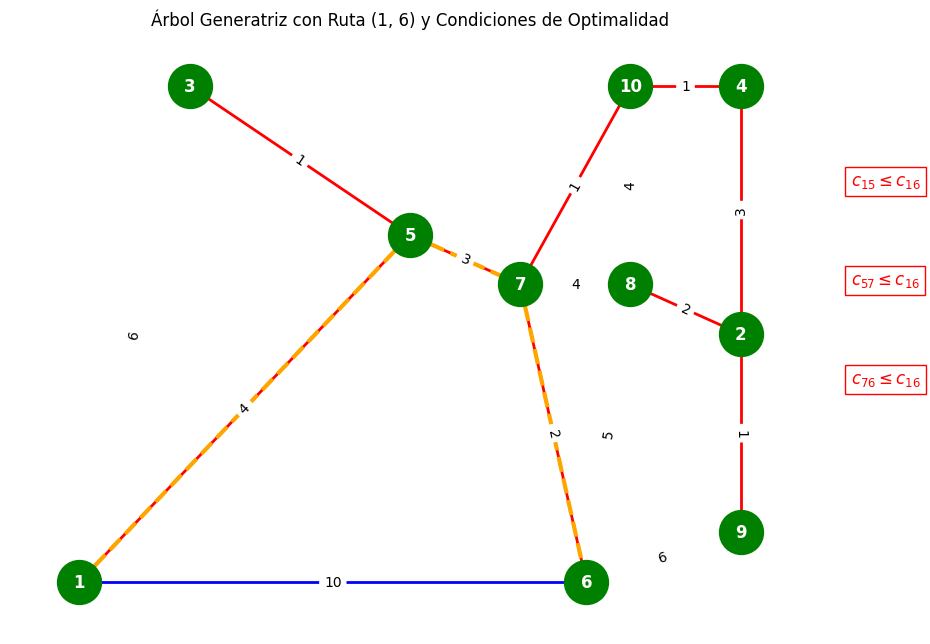

In [76]:
# Lista de los arcos adicionales y la ruta que conecta a 1 con 6
new_edge = [(1, 6)]
path_edges = [(1, 5), (5, 7), (7, 6)]

# Crear una figura
plt.figure(figsize=(8, 6))

# Dibujar los nodos y todas las aristas
nx.draw(G, pos, with_labels=True, node_color='green', node_size=1000, font_weight='bold', font_color='white', edge_color='white')

# Dibujar las aristas del árbol de expansión mínima (MST) en rojo
nx.draw_networkx_edges(G, pos, edgelist=mst.edges(), edge_color='red', width=2)

# Dibujar la arista (1, 6) que se agrega al grafo en azul
nx.draw_networkx_edges(G, pos, edgelist=new_edge, edge_color='blue', width=2)

# Dibujar la ruta que conecta a 1 con 6 en líneas discontinuas rojas
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='orange', width=3, style='dashed')

# Dibujar etiquetas con los pesos de las aristas
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Agregar el cuadro con las desigualdades a la derecha del gráfico
plt.text(3.5, 0.8, r"$c_{15} \leq c_{16}$", fontsize=12, color='red', bbox=dict(facecolor='none', edgecolor='red'))
plt.text(3.5, 0.6, r"$c_{57} \leq c_{16}$", fontsize=12, color='red', bbox=dict(facecolor='none', edgecolor='red'))
plt.text(3.5, 0.4, r"$c_{76} \leq c_{16}$", fontsize=12, color='red', bbox=dict(facecolor='none', edgecolor='red'))

# Mostrar el gráfico
plt.title("Árbol Generatriz con Ruta (1, 6) y Condiciones de Optimalidad")
plt.show()



### Ejemplo visual:
A continuación se muestra cómo identificar aristas ligeras en un corte del grafo.


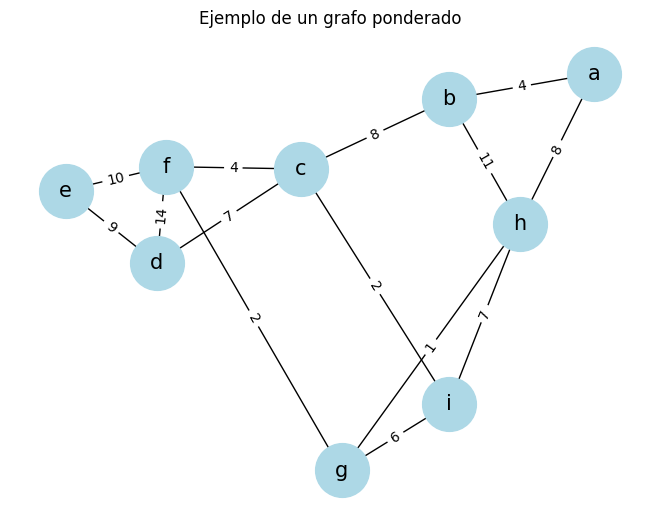

In [77]:
import networkx as nx
import matplotlib.pyplot as plt

# Definimos el grafo de ejemplo con pesos
G = nx.Graph()
edges = [
    ('a', 'b', 4), ('a', 'h', 8), ('b', 'c', 8), ('b', 'h', 11),
    ('c', 'd', 7), ('c', 'f', 4), ('c', 'i', 2), ('d', 'e', 9),
    ('d', 'f', 14), ('e', 'f', 10), ('f', 'g', 2), ('g', 'h', 1),
    ('g', 'i', 6), ('h', 'i', 7)
]
G.add_weighted_edges_from(edges)

# Dibujar el grafo
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1500, font_size=15)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Ejemplo de un grafo ponderado")
plt.show()

**Consecuencias de las anteriores condiciones de optimalidad**

- Una arista es considerada **ligera** si su peso es el mínimo de todas las aristas que cruzan el corte. Esta arista se puede agregar de manera segura al MST sin formar ciclos.

- Para cualquier corte que **respete** un subconjunto $ A $ de aristas que están en algún MST, la arista más ligera que cruza el corte es **segura** para añadir al MST.


**Ejemplo visual**

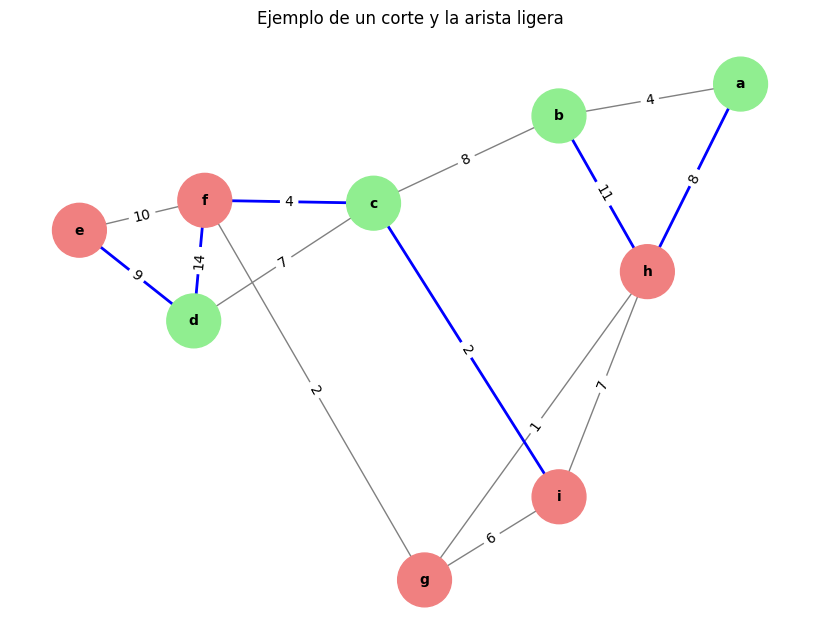

In [78]:

# Visualizar un corte en el grafo
S = {'a', 'b', 'c', 'd'}
V_minus_S = set(G.nodes) - S

plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color=['lightgreen' if n in S else 'lightcoral' for n in G.nodes], node_size=1500, font_size=10, font_weight='bold', edge_color='gray')
nx.draw_networkx_edges(G, pos, edgelist=[(u, v) for u, v in G.edges if (u in S and v in V_minus_S) or (v in S and u in V_minus_S)], edge_color='blue', width=2)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Ejemplo de un corte y la arista ligera")
plt.show()



## Algoritmo de Prim


El algoritmo de Prim es un método voraz (greedy) que construye el MST agregando siempre la arista de menor peso que conecta un nodo en el árbol con un nodo fuera del árbol.

**Algoritmo Prim(G, r)**


1. Crear una cola de prioridad vacía Q
2. Inicializar la lista de aristas MST como vacía
3. Para cada vértice v ∈ V[G]:
     - key[v] ← ∞  # Inicializamos la clave de cada nodo con infinito
     - parent[v] ← NIL  # Inicializamos el padre de cada nodo como nulo
4. key[r] ← 0  # Inicializamos la raíz con clave 0
5. Insertar (0, r) en Q  # Insertamos el nodo raíz en la cola con clave 0
6. Mientras Q no esté vacía:
     - (key[u], u) ← extraerMin(Q)  # Extraer el nodo u con la menor clave
     - Si u no ha sido visitado:
        - Marcar u como visitado
        - Si parent[u] ≠ NIL:
            - MST.append((parent[u], u, key[u]))  # Añadir la arista (parent[u], u) al MST
        - Para cada vecino v de u:
            - Si v no ha sido visitado y w(u, v) < key[v]:  # Si el peso de la arista es menor que la clave actual
                - parent[v] ← u  # Actualizar el padre del nodo v
                - key[v] ← w(u, v)  # Actualizar la clave del nodo v
                - Insertar (key[v], v) en Q  # Insertar v en la cola con la nueva clave
7. Devolver el conjunto de aristas MST



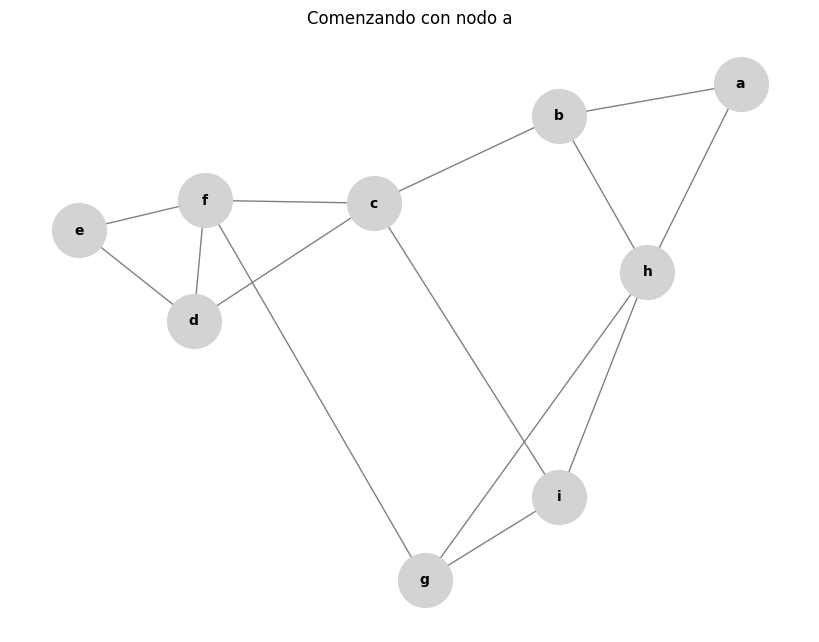

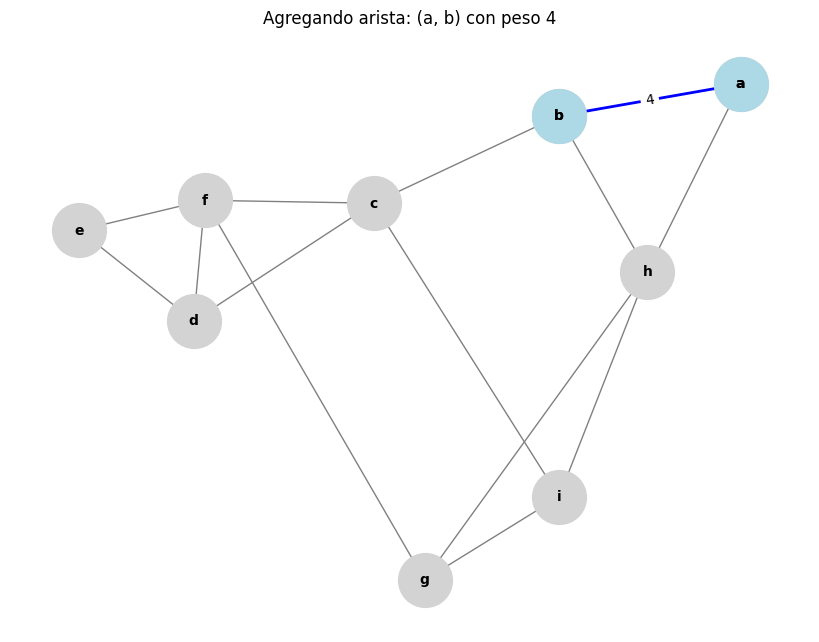

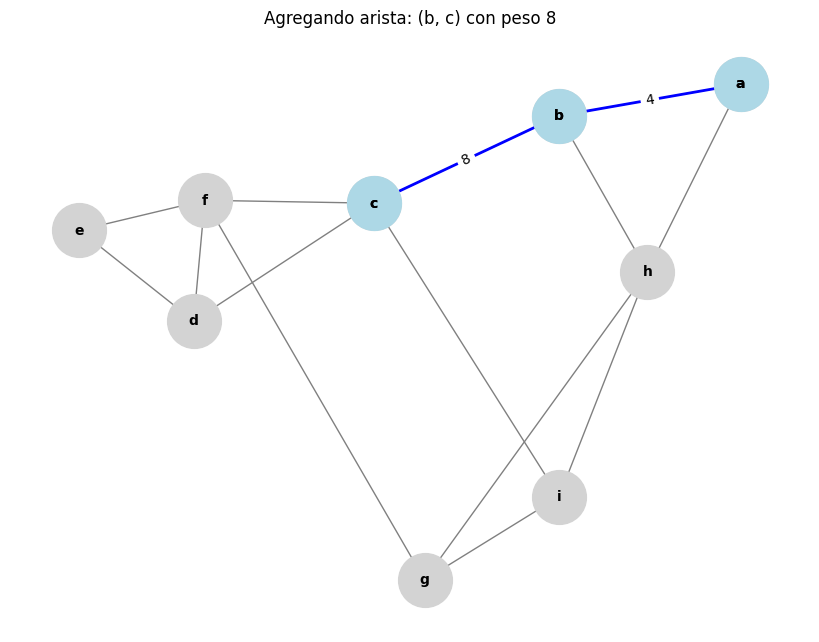

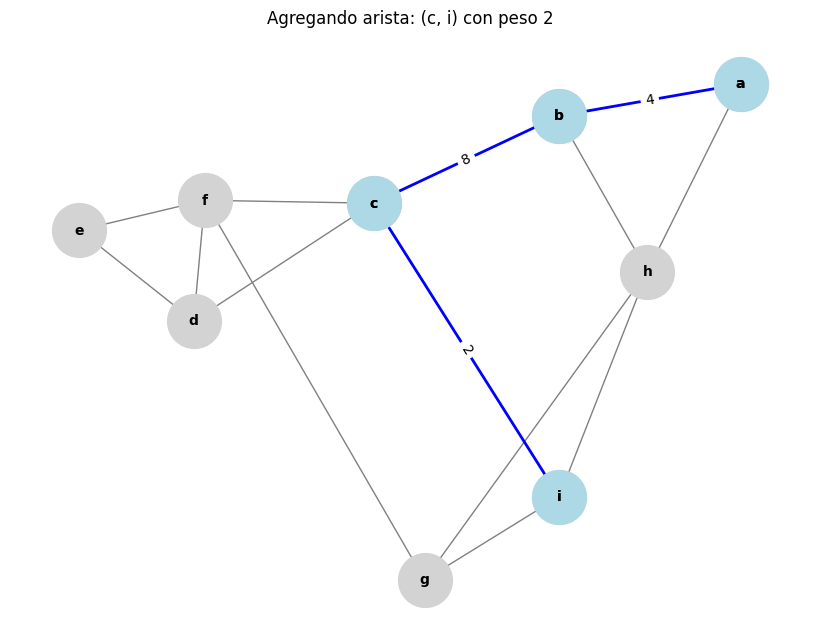

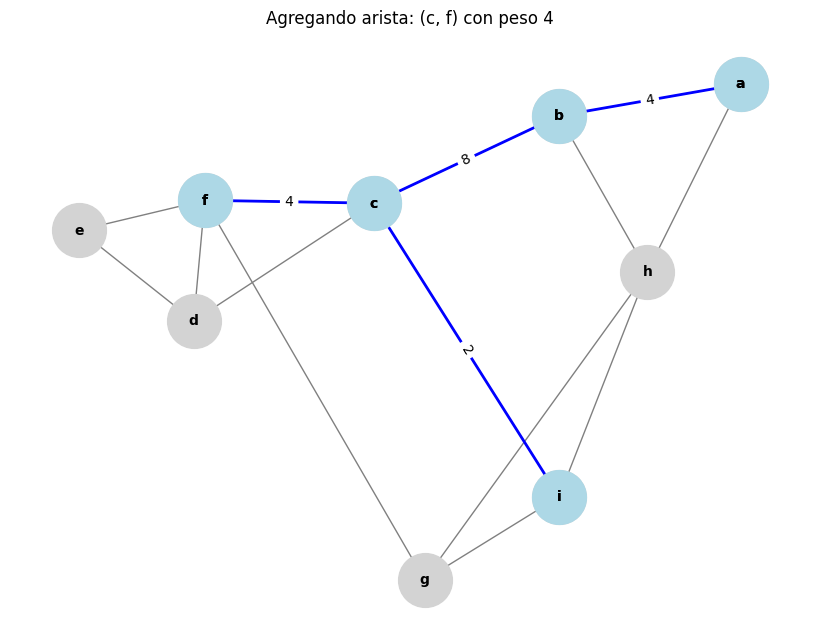

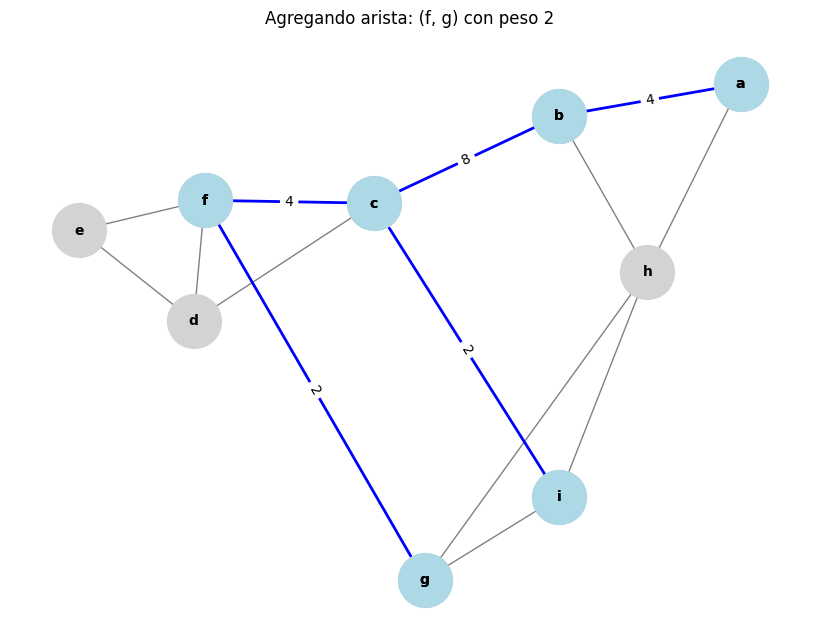

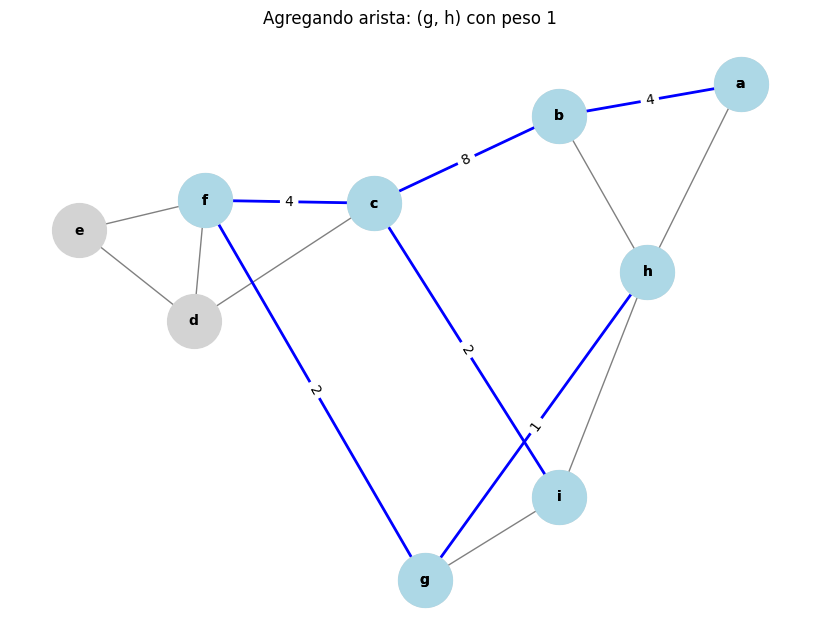

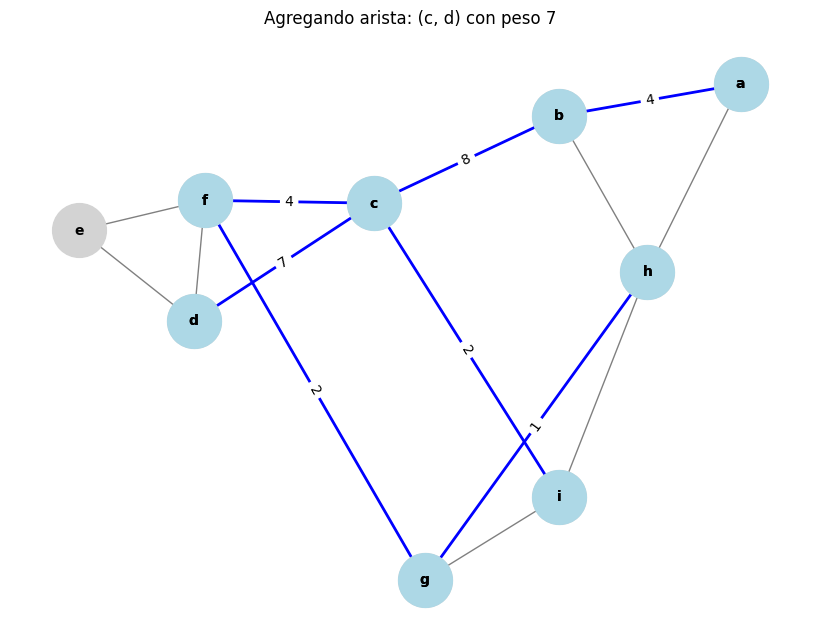

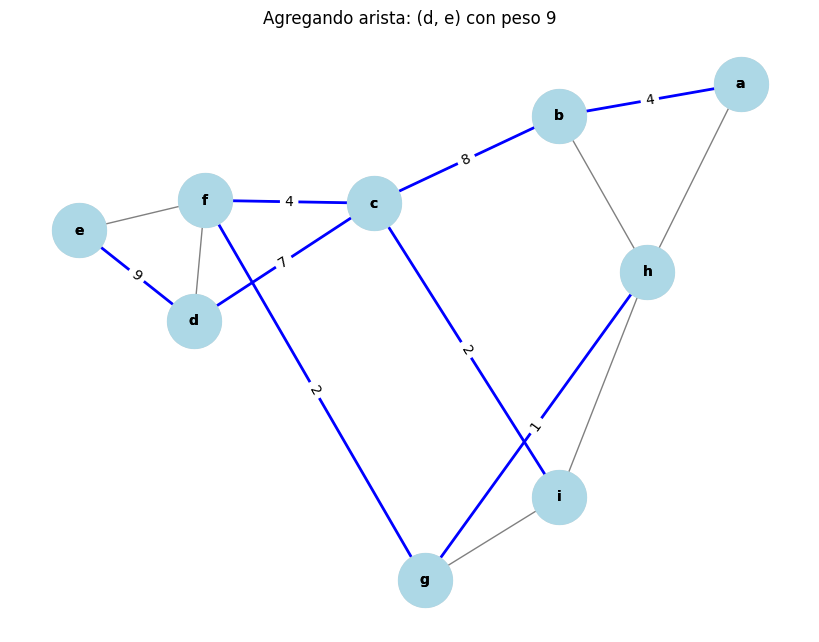

In [79]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Algoritmo de Prim con visualización paso a paso
def prim_mst_visual(graph, start_node):
    mst = []  # Lista de aristas en el MST
    visited = set()  # Conjunto de nodos visitados
    min_heap = [(0, start_node, None)]  # Cola de prioridad (peso, nodo, padre)
    
    pos = nx.spring_layout(graph, seed=42)  # Fijamos el layout para la visualización
    
    while min_heap:
        weight, node, parent = heapq.heappop(min_heap)  # Extraer la arista más ligera
        
        if node not in visited:
            visited.add(node)  # Marcar el nodo como visitado
            
            if parent:
                mst.append((parent, node, weight))  # Agregar arista al MST
            
            # Visualizamos el estado actual del MST
            mst_graph = nx.Graph()
            mst_graph.add_weighted_edges_from(mst)
            plt.figure(figsize=(8, 6))
            nx.draw(graph, pos, with_labels=True, node_color='lightgray', node_size=1500, font_size=10, font_weight='bold', edge_color='gray')
            nx.draw(mst_graph, pos, with_labels=True, node_color='lightblue', node_size=1500, font_size=10, font_weight='bold', edge_color='blue', width=2)
            labels = nx.get_edge_attributes(mst_graph, 'weight')
            nx.draw_networkx_edge_labels(mst_graph, pos, edge_labels=labels)
            plt.title(f"Agregando arista: ({parent}, {node}) con peso {weight}" if parent else f"Comenzando con nodo {node}")
            plt.show()
            
            # Examinar los vecinos del nodo actual
            for neighbor in graph.neighbors(node):
                if neighbor not in visited:
                    edge_weight = graph[node][neighbor]['weight']
                    heapq.heappush(min_heap, (edge_weight, neighbor, node))  # Agregar vecino a la cola
    
    return mst

# Crear un grafo de ejemplo
G = nx.Graph()
edges = [
    ('a', 'b', 4), ('a', 'h', 8), ('b', 'c', 8), ('b', 'h', 11),
    ('c', 'd', 7), ('c', 'f', 4), ('c', 'i', 2), ('d', 'e', 9),
    ('d', 'f', 14), ('e', 'f', 10), ('f', 'g', 2), ('g', 'h', 1),
    ('g', 'i', 6), ('h', 'i', 7)
]
G.add_weighted_edges_from(edges)

# Ejecutar Prim con visualización paso a paso
mst = prim_mst_visual(G, 'a')


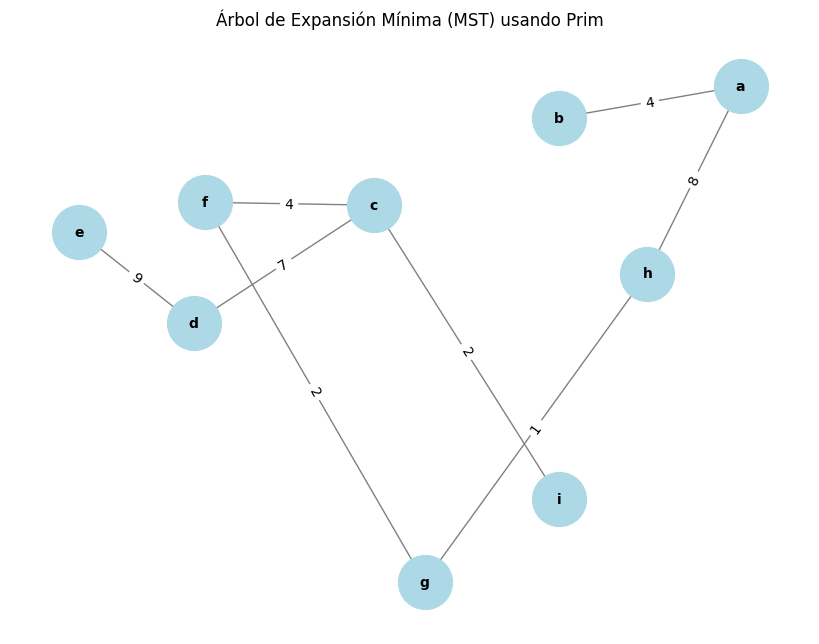

In [80]:

# Función para el algoritmo de Prim
def prim_mst(graph, start_node):
    mst = nx.Graph()
    visited = set([start_node])
    edges = [(graph[start_node][neighbor]['weight'], start_node, neighbor) for neighbor in graph.neighbors(start_node)] # Cola de prioridad (peso, nodo, padre)
    
    while edges:
        edges.sort()  # Extraer la arista más ligera
        weight, u, v = edges.pop(0)
        if v not in visited:
            visited.add(v) # Marcar el nodo como visitado
            mst.add_edge(u, v, weight=weight) # Agregar arista al MST
            # Examinar los vecinos del nodo actual
            for neighbor in graph.neighbors(v):
                if neighbor not in visited:
                    edges.append((graph[v][neighbor]['weight'], v, neighbor))
                    
    return mst

# Ejecutar Prim
mst = prim_mst(G, 'a')

# Visualizar el MST
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G,seed=42)  # Posiciones para grafo original
nx.draw(mst, pos, with_labels=True, node_color='lightblue', node_size=1500, font_size=10, font_weight='bold', edge_color='gray')
labels = nx.get_edge_attributes(mst, 'weight')
nx.draw_networkx_edge_labels(mst, pos, edge_labels=labels)
plt.title("Árbol de Expansión Mínima (MST) usando Prim")
plt.show()


## Algoritmo de Kruskal

El **algoritmo de Kruskal** es otro método voraz para encontrar el **Árbol de Expansión Mínima (MST)** de un grafo. A diferencia del algoritmo de Prim, que expande el MST agregando aristas de menor peso que conectan nodos al árbol parcial, Kruskal comienza con un grafo vacío y añade aristas de menor peso, siempre que no formen un ciclo, hasta conectar todos los nodos.

El enfoque voraz de Kruskal consiste en:

- Ordenar todas las aristas por peso en orden creciente.
- Seleccionar la arista de menor peso y agregarla al MST si no forma un ciclo.





## Pseudocódigo del Algoritmo de Kruskal

A continuación, presentamos el **pseudocódigo** del algoritmo de Kruskal:

```
Algoritmo Kruskal(G)
1. Crear un conjunto vacío T que representará el MST
2. Inicializar un conjunto disjunto D para cada vértice v ∈ V[G]
3. Ordenar las aristas de G en orden creciente de peso
4. Para cada arista (u, v) en el orden de peso creciente:
     Si find(u) ≠ find(v):  # Verificar si u y v están en diferentes componentes
        T ← T ∪ {(u, v)}  # Agregar la arista al MST
        union(u, v)  # Unir los componentes de u y v
5. Devolver el conjunto de aristas T que forma el MST
```



### Descripción de Operaciones Clave:

1. **Inicialización**: Comenzamos con un conjunto de aristas vacío $ T $ y un conjunto disjunto $ D $ para cada vértice. Utilizamos la estructura de datos "Conjuntos Disjuntos" (Union-Find) para gestionar las uniones de componentes conectados.
  
2. **Ordenación de aristas**: Ordenamos todas las aristas por peso en orden ascendente. Esto asegura que seleccionaremos las aristas más ligeras primero, siguiendo el enfoque voraz.

3. **Selección y unión**: Para cada arista $ (u, v) $, verificamos si los vértices $ u $ y $ v $ pertenecen a diferentes componentes utilizando `find(u)` y `find(v)`. Si es así, los unimos utilizando `union(u, v)` y añadimos la arista al MST.

4. **Terminación**: El proceso se repite hasta que el MST contenga $ |V| - 1 $ aristas.






A continuación, se presenta la implementación del algoritmo utilizando la estructura de datos "Union-Find" para gestionar eficientemente los conjuntos disjuntos:


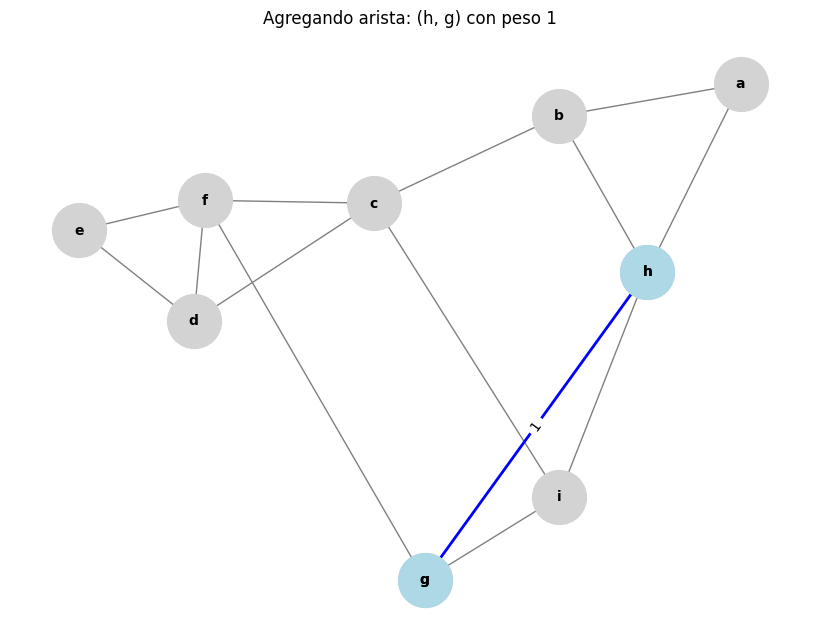

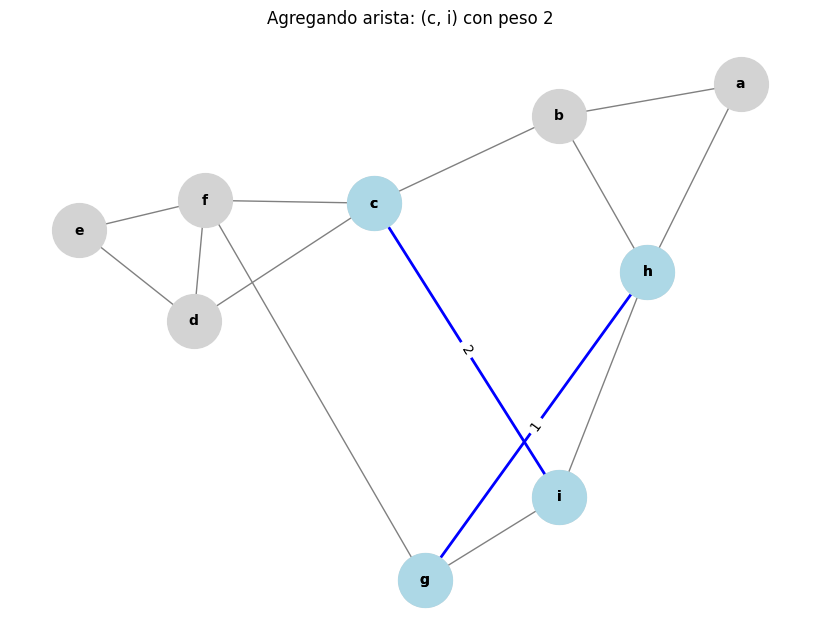

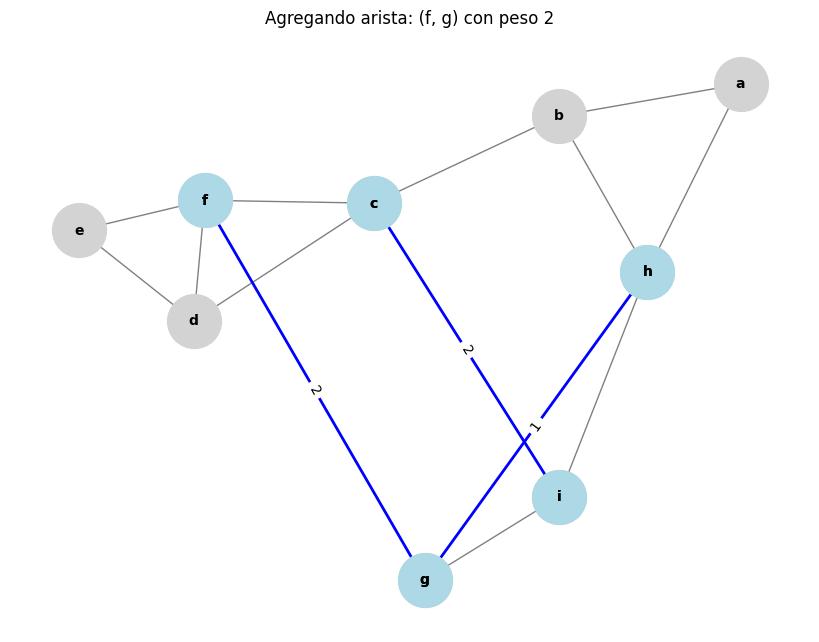

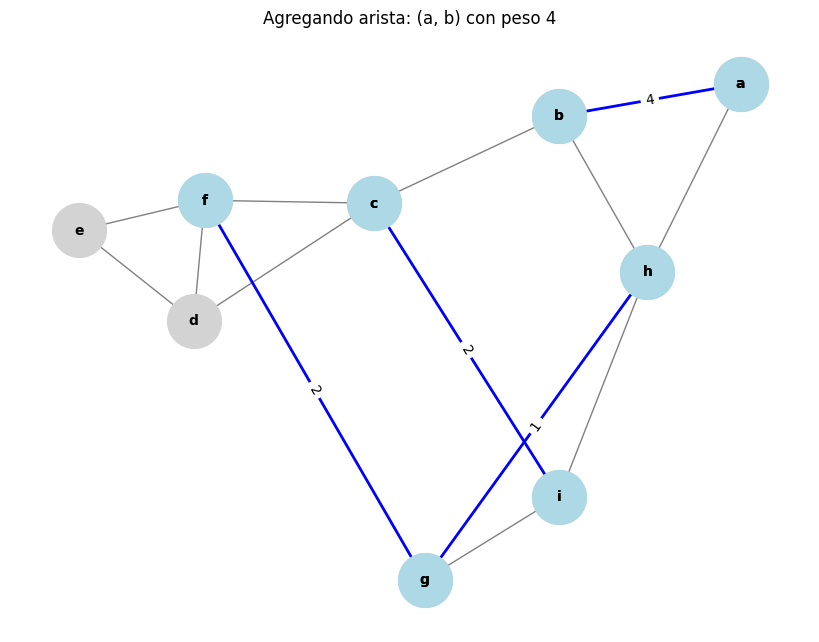

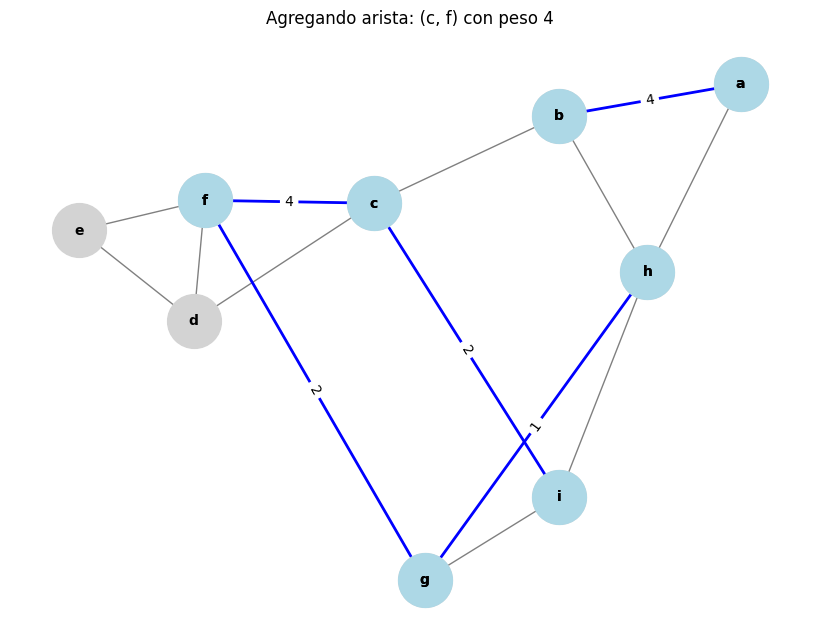

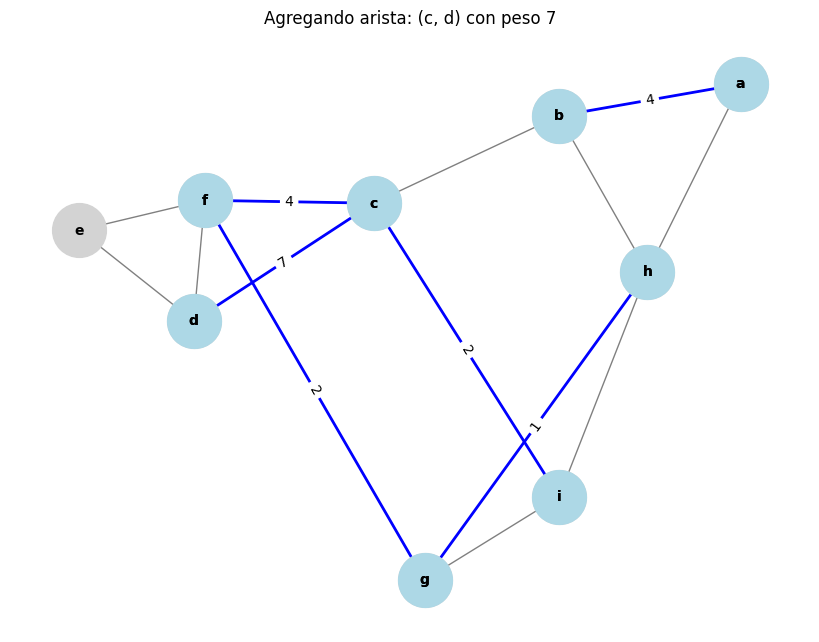

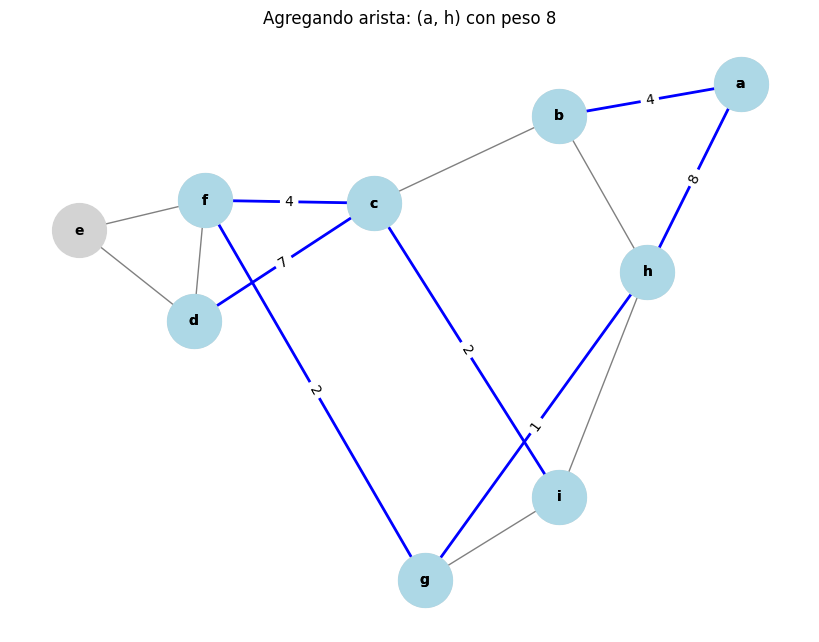

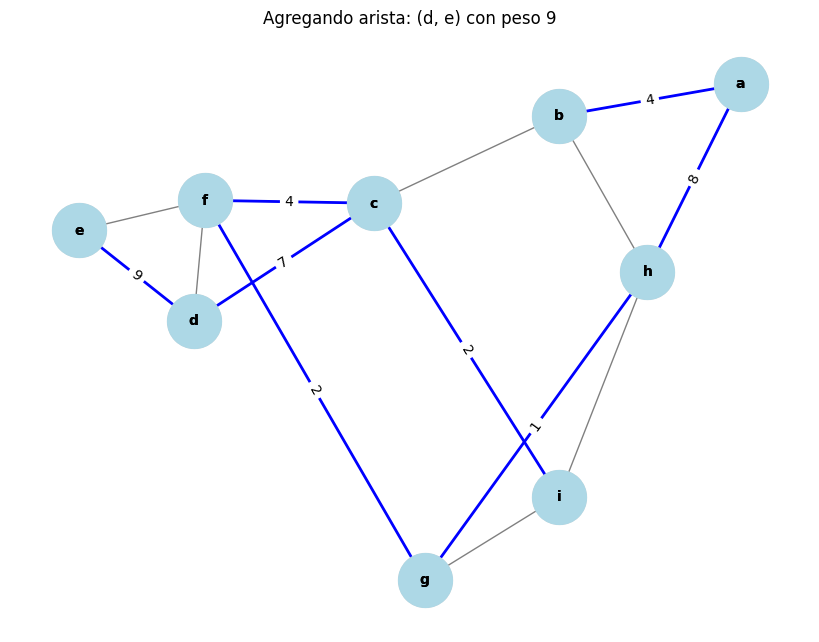

In [81]:
# Importamos las librerías necesarias
import networkx as nx
import matplotlib.pyplot as plt

# Implementación de la estructura Union-Find
class UnionFind:
    def __init__(self, nodes):
        self.parent = {node: node for node in nodes}
        self.rank = {node: 0 for node in nodes}
        
    def find(self, node):
        if self.parent[node] != node:
            self.parent[node] = self.find(self.parent[node])
        return self.parent[node]
    
    def union(self, node1, node2):
        root1 = self.find(node1)
        root2 = self.find(node2)
        
        if root1 != root2:
            if self.rank[root1] > self.rank[root2]:
                self.parent[root2] = root1
            elif self.rank[root1] < self.rank[root2]:
                self.parent[root1] = root2
            else:
                self.parent[root2] = root1
                self.rank[root1] += 1

# Función del algoritmo de Kruskal con visualización paso a paso
def kruskal_mst_visual(graph):
    mst = []  # Lista de aristas en el MST
    edges = list(graph.edges(data='weight'))
    edges.sort(key=lambda x: x[2])  # Ordenar aristas por peso
    uf = UnionFind(graph.nodes)
    
    pos = nx.spring_layout(graph, seed=42)  # Fijamos un layout para la visualización
    
    for u, v, weight in edges:
        if uf.find(u) != uf.find(v):  # Verificar si u y v están en diferentes componentes
            uf.union(u, v)
            mst.append((u, v, weight))
            
            # Visualizamos el estado actual del MST
            mst_graph = nx.Graph()
            mst_graph.add_weighted_edges_from(mst)
            plt.figure(figsize=(8, 6))
            nx.draw(graph, pos, with_labels=True, node_color='lightgray', node_size=1500, font_size=10, font_weight='bold', edge_color='gray')
            nx.draw(mst_graph, pos, with_labels=True, node_color='lightblue', node_size=1500, font_size=10, font_weight='bold', edge_color='blue', width=2)
            labels = nx.get_edge_attributes(mst_graph, 'weight')
            nx.draw_networkx_edge_labels(mst_graph, pos, edge_labels=labels)
            plt.title(f"Agregando arista: ({u}, {v}) con peso {weight}")
            plt.show()
    
    return mst

# Crear un grafo de ejemplo
G = nx.Graph()
edges = [
    ('a', 'b', 4), ('a', 'h', 8), ('b', 'c', 8), ('b', 'h', 11),
    ('c', 'd', 7), ('c', 'f', 4), ('c', 'i', 2), ('d', 'e', 9),
    ('d', 'f', 14), ('e', 'f', 10), ('f', 'g', 2), ('g', 'h', 1),
    ('g', 'i', 6), ('h', 'i', 7)
]
G.add_weighted_edges_from(edges)

# Ejecutar Kruskal con visualización paso a paso
mst = kruskal_mst_visual(G)



In [82]:
import networkx as nx
import matplotlib.pyplot as plt

# Implementación de la estructura Union-Find
class UnionFind:
    def __init__(self, nodes):
        self.parent = {node: node for node in nodes}
        self.rank = {node: 0 for node in nodes}
        
    def find(self, node):
        if self.parent[node] != node:
            self.parent[node] = self.find(self.parent[node])
        return self.parent[node]
    
    def union(self, node1, node2):
        root1 = self.find(node1)
        root2 = self.find(node2)
        
        if root1 != root2:
            if self.rank[root1] > self.rank[root2]:
                self.parent[root2] = root1
            elif self.rank[root1] < self.rank[root2]:
                self.parent[root1] = root2
            else:
                self.parent[root2] = root1
                self.rank[root1] += 1

# Algoritmo de Kruskal
def kruskal_mst(graph):
    mst = []  # Lista de aristas en el MST
    edges = list(graph.edges(data='weight'))
    edges.sort(key=lambda x: x[2])  # Ordenar aristas por peso
    
    uf = UnionFind(graph.nodes)
    
    for u, v, weight in edges:
        if uf.find(u) != uf.find(v):  # Verificar si u y v están en diferentes componentes
            uf.union(u, v)
            mst.append((u, v, weight))
    
    return mst


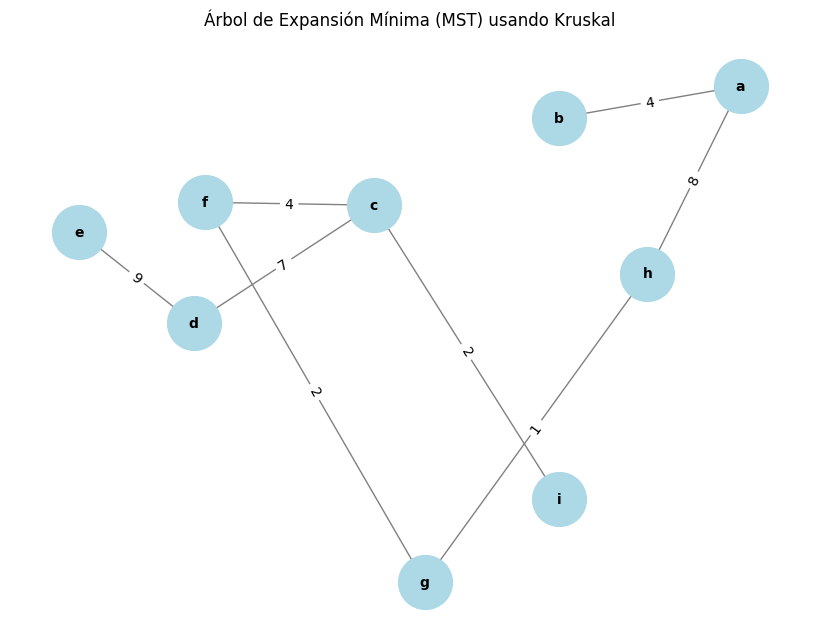

In [83]:
# Crear un grafo de ejemplo
G = nx.Graph()
edges = [
    ('a', 'b', 4), ('a', 'h', 8), ('b', 'c', 8), ('b', 'h', 11),
    ('c', 'd', 7), ('c', 'f', 4), ('c', 'i', 2), ('d', 'e', 9),
    ('d', 'f', 14), ('e', 'f', 10), ('f', 'g', 2), ('g', 'h', 1),
    ('g', 'i', 6), ('h', 'i', 7)
]
G.add_weighted_edges_from(edges)

# Ejecutar Kruskal
mst = kruskal_mst(G)

# Visualizar el MST
mst_graph = nx.Graph()
mst_graph.add_weighted_edges_from(mst)

pos = nx.spring_layout(G, seed=42)  # Fijar layout para consistencia
plt.figure(figsize=(8, 6))

# Visualizar el MST
nx.draw(mst_graph, pos, with_labels=True, node_color='lightblue', node_size=1500, font_size=10, font_weight='bold', edge_color='gray')
labels = nx.get_edge_attributes(mst_graph, 'weight')
nx.draw_networkx_edge_labels(mst_graph, pos, edge_labels=labels)
plt.title("Árbol de Expansión Mínima (MST) usando Kruskal")
plt.show()


### Explicación del Código:

1. **Union-Find**: Implementamos la estructura de datos "Union-Find" para gestionar eficientemente la unión y la verificación de conjuntos disjuntos.
2. **Kruskal**: Ordenamos las aristas del grafo y seleccionamos la arista más ligera que conecta dos componentes disjuntos, añadiéndola al MST.
3. **Visualización**: El MST resultante se muestra utilizando `networkx` y `matplotlib`.


## Comparación con el Algoritmo de Prim

| **Aspecto**             | **Kruskal**                           | **Prim**                              |
|-------------------------|--------------------------------------|---------------------------------------|
| Estrategia              | Selección global de aristas           | Expansión desde un nodo inicial       |
| Uso de estructura de datos | Union-Find para gestión de componentes | Cola de prioridad para aristas        |
| Eficiencia en grafos    | Adecuado para grafos dispersos        | Adecuado para grafos densos           |



## Ejercicios 

**Problema 1: Árbol de Expansión Mínima con Restricciones**

1. Objetivo: Extender el problema de MST para incorporar restricciones adicionales.

2. Enunciado: Dado un grafo con nodos representando ciudades y aristas representando carreteras entre ellas, ahora se introduce una restricción en la construcción del MST: ciertas carreteras ya construidas no se pueden eliminar. Modifique los algoritmos de Prim y Kruskal para tener en cuenta estas restricciones de manera que el MST resultante sea el de menor costo que también respete las carreteras preexistentes.

- Describa cómo modificar ambos algoritmos para cumplir con la restricción.
- Implemente las modificaciones y verifique que el MST respete las carreteras ya existentes.
- Analice el impacto de esta restricción en la complejidad del problema. De forma empirica intente decidir que ocurre observando los tiempos de ejecución.




**Problema 2: Algoritmos Aproximados para el Problema del Viajante (TSP) Usando MST**


1. Objetivo: Conectar el MST con un problema NP-completo.

2. Enunciado: El Problema del Viajante (TSP) es uno de los problemas clásicos más difíciles de resolver de manera exacta, ya que es NP-completo. Sin embargo, se puede usar un Árbol de Expansión Mínima para encontrar una solución aproximada.

- Describa cómo usar un Árbol de Expansión Mínima para construir una solución aproximada al TSP.
- Implemente un algoritmo que resuelva el TSP utilizando un MST.
- Calcule el factor de aproximación en diferentes grafos y analice la calidad de la solución, comparandola con el modelo exacto.








**Problema 3: Efecto de los Ciclos en la Formación del MST**

1. Objetivo: Estudiar el impacto de los ciclos en la construcción de MST.

2. Enunciado: Los algoritmos de Prim y Kruskal evitan la formación de ciclos al seleccionar aristas para el MST. Sin embargo, considere un escenario en el que un ciclo se permite temporalmente y luego se reduce de forma controlada para obtener un MST.

- Explique teóricamente por qué los algoritmos tradicionales evitan ciclos y cómo podrían adaptarse para "permitir" ciclos de manera temporal.
- Implemente una versión modificada del algoritmo de Kruskal que permita un ciclo temporalmente y luego lo elimine.
- Analice el impacto de esta modificación en la eficiencia y la corrección del algoritmo.
